<a href="https://colab.research.google.com/github/Karthikeya81/OPENCV_LAB_RECORD/blob/main/Experiment_13_Motion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 13 Motion Detection

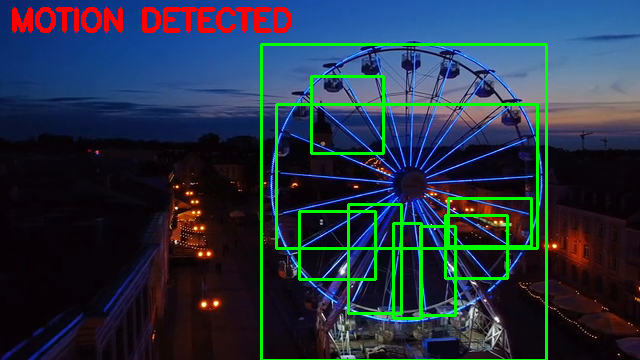

Video motion detection complete!


In [1]:
# Import necessary libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
from IPython.display import clear_output
import time

print("Upload a short video file (.mp4) for motion detection:")
# Prompt the user to upload a video
uploaded = files.upload()
video_filename = next(iter(uploaded))

# Create a VideoCapture object to read the video
cap = cv2.VideoCapture(video_filename)

# Read the very first two frames of the video to start the comparison
ret, frame1 = cap.read()
ret, frame2 = cap.read()

# We will limit this to 50 frames so Colab doesn't crash or run out of memory
frame_count = 0

while cap.isOpened() and frame_count < 50:
    # If we run out of frames, break the loop
    if not ret or frame1 is None or frame2 is None:
        break

    # 1. Find the absolute difference between the two frames
    diff = cv2.absdiff(frame1, frame2)

    # 2. Convert the difference to grayscale to make processing easier
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    # 3. Apply Gaussian Blur to smooth out the noise (like static or lighting changes)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 4. Apply a threshold. Any difference stronger than 20 turns pure white (255)
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

    # 5. Dilate the white shapes to fill in any holes or gaps
    dilated = cv2.dilate(thresh, None, iterations=3)

    # 6. Find the contours (outlines) of the white motion blobs
    contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # 7. Draw rectangles around the moving objects
    for contour in contours:
        # Ignore tiny movements (like a leaf rustling in the wind)
        if cv2.contourArea(contour) < 900:
            continue
        # Get the coordinates for a bounding box
        x, y, w, h = cv2.boundingRect(contour)
        # Draw a green rectangle on the original frame
        cv2.rectangle(frame1, (x, y), (x+w, y+h), (0, 255, 0), 2)
        # Add a text warning!
        cv2.putText(frame1, "MOTION DETECTED", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

    # Clear the previous frame from the Colab output area
    clear_output(wait=True)
    # Display the current frame with the green boxes drawn on it
    cv2_imshow(frame1)

    # Setup the next loop: Frame 1 becomes Frame 2, and we read a new Frame 2
    frame1 = frame2
    ret, frame2 = cap.read()
    frame_count += 1

    # Add a tiny delay so it plays at a normal visual speed
    time.sleep(0.1)

# Release the video memory
cap.release()
print("Video motion detection complete!")

Comparing: 'pic2 (2).png' against 'pic3 (2).png'


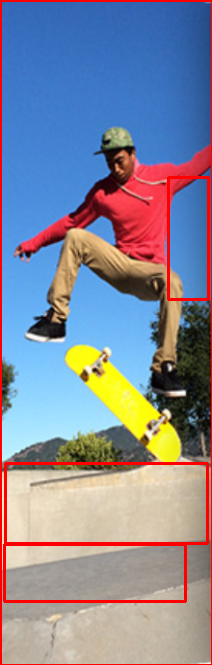


Image sequence processing complete!


In [4]:
# Import necessary libraries
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
from IPython.display import clear_output
import time

print("Upload a sequence of images (e.g., pic1.jpg, pic2.jpg, pic3.jpg):")
print("TIP: You can select multiple files at once!")
# Prompt user to upload multiple images
uploaded_seq = files.upload()

# Sort the filenames alphabetically so they are processed in chronological order
image_files = sorted(uploaded_seq.keys())

if len(image_files) < 2:
    print("Error: You need to upload at least TWO images to detect motion!")
else:
    # Read the very first image to serve as our baseline (Frame 1)
    frame1 = cv2.imread(image_files[0])

    # Loop through the remaining images starting from the second one
    for i in range(1, len(image_files)):
        # Read the next image in the sequence (Frame 2)
        frame2 = cv2.imread(image_files[i])

        # --- THE SIZE FIX ---
        # Force frame2 to be the exact same width and height as frame1
        # frame1.shape[1] is the width, frame1.shape[0] is the height
        frame2 = cv2.resize(frame2, (frame1.shape[1], frame1.shape[0]))
        # --------------------

        # Calculate the mathematical difference between the two frames
        diff = cv2.absdiff(frame1, frame2)

        # Convert to grayscale
        gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

        # Blur to remove minor static/noise
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # Threshold to turn any significant difference into pure white
        _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

        # Dilate to fill in gaps in the white shapes
        dilated = cv2.dilate(thresh, None, iterations=3)

        # Find the outlines (contours) of those white shapes
        contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        # Create a copy of frame 2 to draw our red boxes on
        display_frame = frame2.copy()

        for contour in contours:
            # Ignore tiny movements (noise)
            if cv2.contourArea(contour) < 500:
                continue

            # Get the coordinates for the bounding box
            x, y, w, h = cv2.boundingRect(contour)

            # Draw a Red rectangle around the movement
            cv2.rectangle(display_frame, (x, y), (x+w, y+h), (0, 0, 255), 2)

        # Refresh the screen to show the new frame
        clear_output(wait=True)
        print(f"Comparing: '{image_files[i-1]}' against '{image_files[i]}'")

        # Display the image with the bounding box
        cv2_imshow(display_frame)

        # Pause for 1.5 seconds so you can actually see the result
        time.sleep(1.5)

        # Update frame1 to the current image so it can be compared to the next one
        frame1 = frame2

print("\nImage sequence processing complete!")